In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from PIL import Image

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.lower().endswith('.zip'):
            print(os.path.join(root, file))

/content/drive/MyDrive/deepfake_project.zip
/content/drive/MyDrive/archive (3).zip
/content/drive/MyDrive/AI Healthcare/archive (7).zip


In [5]:
zip_path = "/content/drive/MyDrive/archive (7).zip"

In [6]:
zip_path = "/content/drive/MyDrive/Datasets/archive (7).zip"

In [8]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.lower() == "archive (7).zip":
            print("FOUND:")
            print(os.path.join(root, file))

FOUND:
/content/drive/MyDrive/AI Healthcare/archive (7).zip


In [9]:
zip_path = "/content/drive/MyDrive/AI Healthcare/archive (7).zip"

In [12]:
import zipfile
import os

extract_path = "/content/chest_xray"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [13]:
for root, dirs, files in os.walk("/content/chest_xray"):
    level = root.replace("/content/chest_xray", "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

chest_xray/
    chest_xray/
        chest_xray/
            test/
                NORMAL/
                PNEUMONIA/
            train/
                NORMAL/
                PNEUMONIA/
            val/
                NORMAL/
                PNEUMONIA/
        test/
            NORMAL/
            PNEUMONIA/
        __MACOSX/
            chest_xray/
                test/
                    NORMAL/
                    PNEUMONIA/
                train/
                    NORMAL/
                    PNEUMONIA/
                val/
                    NORMAL/
                    PNEUMONIA/
        train/
            NORMAL/
            PNEUMONIA/
        val/
            NORMAL/
            PNEUMONIA/


In [14]:
import os

base_path = "/content/chest_xray"

print("Possible dataset folders:\n")

for root, dirs, files in os.walk(base_path):

    # Ignore Mac metadata
    if "__MACOSX" in root:
        continue

    required_folders = {"train", "test", "val"}

    if required_folders.issubset(set(dirs)):

        print(root)

Possible dataset folders:

/content/chest_xray/chest_xray
/content/chest_xray/chest_xray/chest_xray


In [15]:
classes = ["NORMAL", "PNEUMONIA"]

for root, dirs, files in os.walk(base_path):

    if "__MACOSX" in root:
        continue

    if {"train", "test", "val"}.issubset(set(dirs)):

        print("\n====================================")
        print("Dataset root:", root)
        print("====================================")

        for split in ["train", "test", "val"]:

            for class_name in classes:

                folder = os.path.join(
                    root,
                    split,
                    class_name
                )

                if os.path.exists(folder):

                    count = len([
                        f for f in os.listdir(folder)
                        if f.lower().endswith(
                            (".jpg", ".jpeg", ".png")
                        )
                    ])

                    print(
                        f"{split:5} | "
                        f"{class_name:10} | "
                        f"{count} images"
                    )


Dataset root: /content/chest_xray/chest_xray
train | NORMAL     | 1341 images
train | PNEUMONIA  | 3875 images
test  | NORMAL     | 234 images
test  | PNEUMONIA  | 390 images
val   | NORMAL     | 8 images
val   | PNEUMONIA  | 8 images

Dataset root: /content/chest_xray/chest_xray/chest_xray
train | NORMAL     | 1341 images
train | PNEUMONIA  | 3875 images
test  | NORMAL     | 234 images
test  | PNEUMONIA  | 390 images
val   | NORMAL     | 8 images
val   | PNEUMONIA  | 8 images


In [16]:
dataset_candidates = []

for root, dirs, files in os.walk(base_path):

    if "__MACOSX" in root:
        continue

    if {"train", "test", "val"}.issubset(set(dirs)):

        dataset_candidates.append(root)

print("Dataset candidates:")

for path in dataset_candidates:
    print(path)

Dataset candidates:
/content/chest_xray/chest_xray
/content/chest_xray/chest_xray/chest_xray


In [17]:
classes = ["NORMAL", "PNEUMONIA"]

for root in dataset_candidates:

    print("\n" + "=" * 60)
    print("DATASET ROOT:")
    print(root)
    print("=" * 60)

    total = 0

    for split in ["train", "test", "val"]:

        print(f"\n{split.upper()}")

        for class_name in classes:

            folder = os.path.join(
                root,
                split,
                class_name
            )

            count = 0

            if os.path.exists(folder):
                count = len([
                    f for f in os.listdir(folder)
                    if f.lower().endswith(
                        (".jpg", ".jpeg", ".png")
                    )
                ])

            print(f"{class_name:10} : {count}")

            total += count

    print("\nTOTAL IMAGES:", total)


DATASET ROOT:
/content/chest_xray/chest_xray

TRAIN
NORMAL     : 1341
PNEUMONIA  : 3875

TEST
NORMAL     : 234
PNEUMONIA  : 390

VAL
NORMAL     : 8
PNEUMONIA  : 8

TOTAL IMAGES: 5856

DATASET ROOT:
/content/chest_xray/chest_xray/chest_xray

TRAIN
NORMAL     : 1341
PNEUMONIA  : 3875

TEST
NORMAL     : 234
PNEUMONIA  : 390

VAL
NORMAL     : 8
PNEUMONIA  : 8

TOTAL IMAGES: 5856


In [18]:
dataset_path = "/content/chest_xray/chest_xray"

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/chest_xray/chest_xray"

classes = ["NORMAL", "PNEUMONIA"]

image_paths = []
labels = []

for split in ["train", "test", "val"]:

    for class_name in classes:

        folder = os.path.join(
            dataset_path,
            split,
            class_name
        )

        for file in os.listdir(folder):

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):

                image_paths.append(
                    os.path.join(folder, file)
                )

                labels.append(class_name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))

Total images: 5856


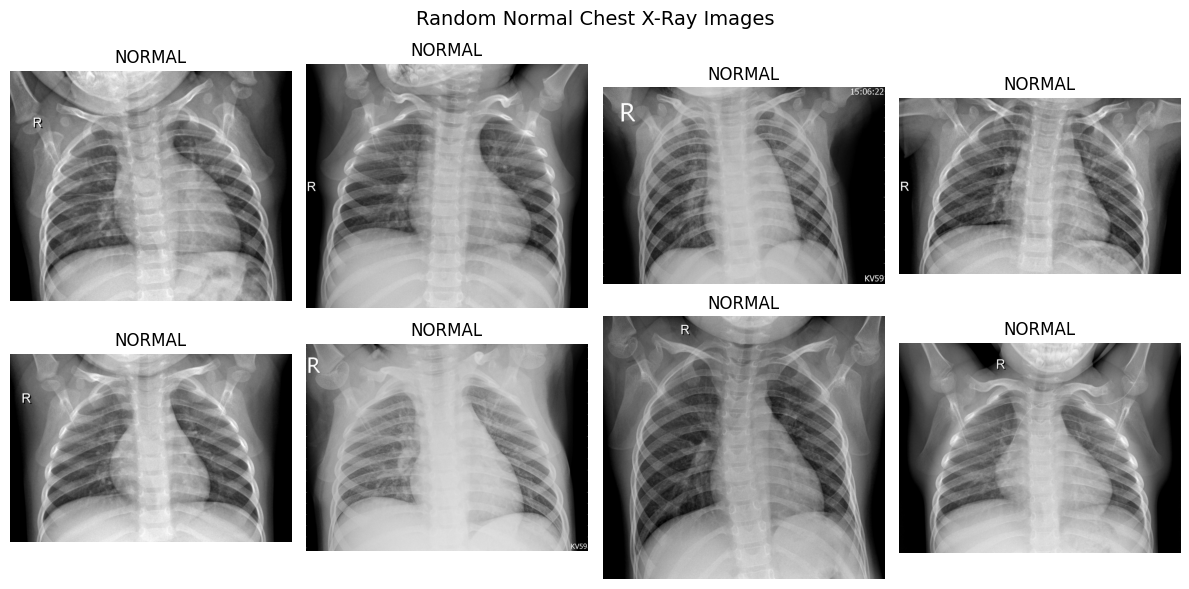

In [20]:
normal_images = df[
    df["label"] == "NORMAL"
]["image_path"].sample(
    8,
    random_state=42
)

fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6)
)

for ax, image_path in zip(
    axes.ravel(),
    normal_images
):

    image = Image.open(image_path)

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title("NORMAL")
    ax.axis("off")

plt.suptitle(
    "Random Normal Chest X-Ray Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

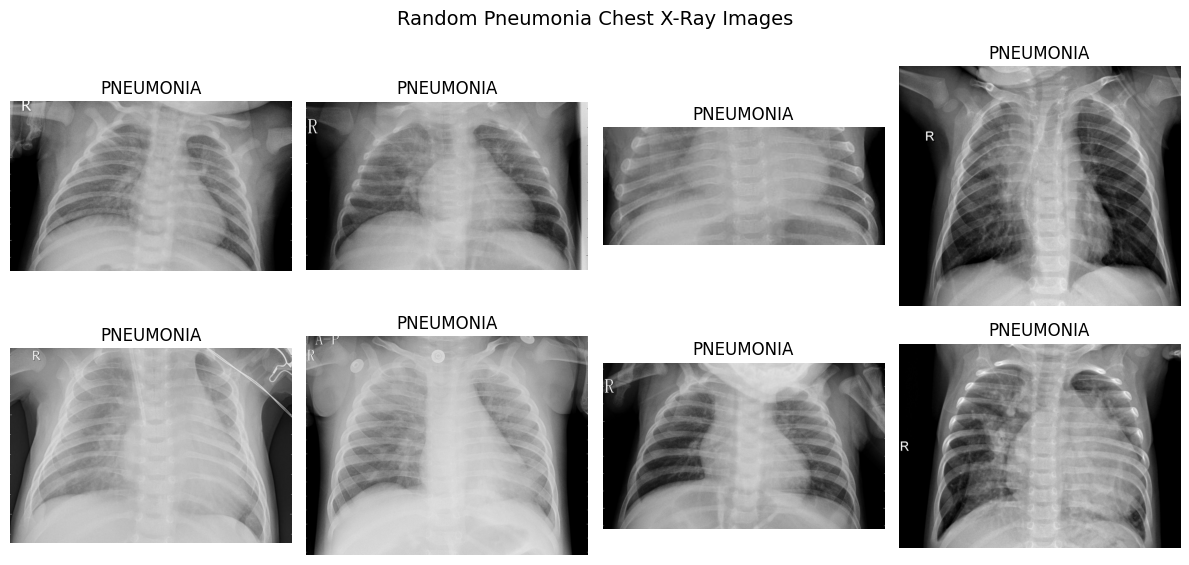

In [21]:
pneumonia_images = df[
    df["label"] == "PNEUMONIA"
]["image_path"].sample(
    8,
    random_state=42
)

fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6)
)

for ax, image_path in zip(
    axes.ravel(),
    pneumonia_images
):

    image = Image.open(image_path)

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title("PNEUMONIA")
    ax.axis("off")

plt.suptitle(
    "Random Pneumonia Chest X-Ray Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [22]:
class_counts = df["label"].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


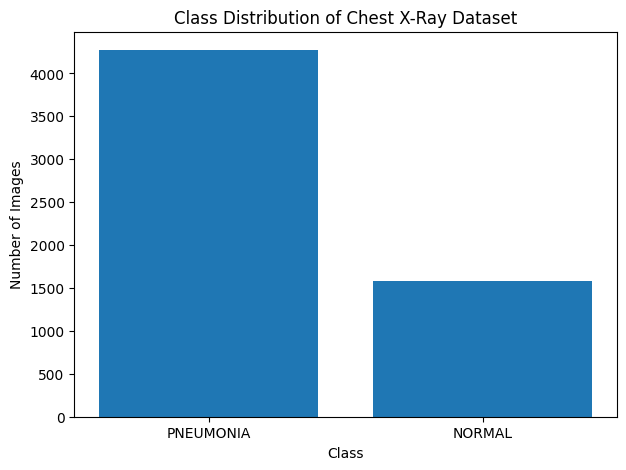

In [23]:
plt.figure(figsize=(7, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title(
    "Class Distribution of Chest X-Ray Dataset"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [24]:
class_percentages = (
    df["label"]
    .value_counts(normalize=True)
    * 100
)

print(
    class_percentages.round(2)
)

label
PNEUMONIA    72.97
NORMAL       27.03
Name: proportion, dtype: float64


In [25]:
IMG_SIZE = 128

def load_image(image_path):

    image = Image.open(
        image_path
    ).convert("L")

    image = image.resize(
        (IMG_SIZE, IMG_SIZE)
    )

    return np.array(image)

In [26]:
from skimage.feature import hog

In [27]:
def extract_hog(image):

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return features

In [28]:
def extract_hog(image):

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return features

In [30]:
sample_image_path = df['image_path'].iloc[0]
sample_image = load_image(sample_image_path)

hog_features = extract_hog(
    sample_image
)

print(
    "HOG feature vector shape:",
    hog_features.shape
)

HOG feature vector shape: (8100,)


In [31]:
from skimage.feature import local_binary_pattern

In [32]:
def extract_lbp(image):

    radius = 1
    n_points = 8 * radius

    lbp = local_binary_pattern(
        image,
        n_points,
        radius,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype(float)
    hist /= (hist.sum() + 1e-6)

    return hist

In [33]:
lbp_features = extract_lbp(sample_image)

print(
    "LBP feature vector shape:",
    lbp_features.shape
)

LBP feature vector shape: (10,)


In [34]:
from skimage.feature import (
    graycomatrix,
    graycoprops
)

In [35]:
def extract_glcm(image):

    image_reduced = (
        image / 32
    ).astype(np.uint8)

    glcm = graycomatrix(
        image_reduced,
        distances=[1],
        angles=[0],
        levels=8,
        symmetric=True,
        normed=True
    )

    properties = [
        "contrast",
        "dissimilarity",
        "homogeneity",
        "energy",
        "correlation"
    ]

    features = []

    for prop in properties:

        features.append(
            graycoprops(
                glcm,
                prop
            )[0, 0]
        )

    return np.array(features)

In [36]:
glcm_features = extract_glcm(sample_image)

print(
    "GLCM feature vector:",
    glcm_features
)

print(
    "GLCM feature vector shape:",
    glcm_features.shape
)

GLCM feature vector: [0.28038878 0.24606299 0.88034898 0.31315579 0.96797181]
GLCM feature vector shape: (5,)


In [37]:
all_features = []
all_labels = []

for i, row in df.iterrows():

    image = load_image(row["image_path"])

    # HOG features
    hog_feat = extract_hog(image)

    # LBP features
    lbp_feat = extract_lbp(image)

    # GLCM features
    glcm_feat = extract_glcm(image)

    # Combine all features
    combined_features = np.concatenate([
        hog_feat,
        lbp_feat,
        glcm_feat
    ])

    all_features.append(combined_features)

    # NORMAL = 0, PNEUMONIA = 1
    label = 0 if row["label"] == "NORMAL" else 1

    all_labels.append(label)

all_features = np.array(all_features)
all_labels = np.array(all_labels)

print("Feature matrix shape:", all_features.shape)
print("Labels shape:", all_labels.shape)

Feature matrix shape: (5856, 8115)
Labels shape: (5856,)


In [38]:
all_features = []
all_labels = []

for i, row in df.iterrows():

    image = load_image(row["image_path"])

    # HOG
    hog_feat = extract_hog(image)

    # LBP
    lbp_feat = extract_lbp(image)

    # GLCM
    glcm_feat = extract_glcm(image)

    # Combine all features
    combined_features = np.concatenate([
        hog_feat,
        lbp_feat,
        glcm_feat
    ])

    all_features.append(combined_features)

    # NORMAL = 0, PNEUMONIA = 1
    label = 0 if row["label"] == "NORMAL" else 1
    all_labels.append(label)

all_features = np.array(all_features)
all_labels = np.array(all_labels)

print("Feature matrix shape:", all_features.shape)
print("Labels shape:", all_labels.shape)

Feature matrix shape: (5856, 8115)
Labels shape: (5856,)


In [39]:
all_features = []
all_labels = []

for i, row in df.iterrows():

    image = load_image(row["image_path"])

    # HOG
    hog_feat = extract_hog(image)

    # LBP
    lbp_feat = extract_lbp(image)

    # GLCM
    glcm_feat = extract_glcm(image)

    # Combine all features
    combined_features = np.concatenate([
        hog_feat,
        lbp_feat,
        glcm_feat
    ])

    all_features.append(combined_features)

    # NORMAL = 0, PNEUMONIA = 1
    label = 0 if row["label"] == "NORMAL" else 1
    all_labels.append(label)

all_features = np.array(all_features)
all_labels = np.array(all_labels)

print("Feature matrix shape:", all_features.shape)
print("Labels shape:", all_labels.shape)

Feature matrix shape: (5856, 8115)
Labels shape: (5856,)


In [40]:
all_features = []
all_labels = []

for i, row in df.iterrows():

    image = load_image(row["image_path"])

    # HOG
    hog_feat = extract_hog(image)

    # LBP
    lbp_feat = extract_lbp(image)

    # GLCM
    glcm_feat = extract_glcm(image)

    # Combine all features
    combined_features = np.concatenate([
        hog_feat,
        lbp_feat,
        glcm_feat
    ])

    all_features.append(combined_features)

    # NORMAL = 0, PNEUMONIA = 1
    label = 0 if row["label"] == "NORMAL" else 1
    all_labels.append(label)

all_features = np.array(all_features)
all_labels = np.array(all_labels)

print("Feature matrix shape:", all_features.shape)
print("Labels shape:", all_labels.shape)

Feature matrix shape: (5856, 8115)
Labels shape: (5856,)


In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_temp, y_train, y_temp = train_test_split(
    all_features,
    all_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_labels
)

In [43]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [44]:
print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation set:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (4099, 8115)
y_train: (4099,)

Validation set:
X_val: (878, 8115)
y_val: (878,)

Testing set:
X_test: (879, 8115)
y_test: (879,)


In [45]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training class distribution:
1    2991
0    1108
Name: count, dtype: int64

Validation class distribution:
1    641
0    237
Name: count, dtype: int64

Testing class distribution:
1    641
0    238
Name: count, dtype: int64


In [46]:
# Prepare images for CNN

images = []
cnn_labels = []

for i, row in df.iterrows():

    image = load_image(row["image_path"])

    # Normalize pixel values from 0-255 to 0-1
    image = image.astype("float32") / 255.0

    images.append(image)

    # NORMAL = 0
    # PNEUMONIA = 1
    label = 0 if row["label"] == "NORMAL" else 1

    cnn_labels.append(label)

images = np.array(images)
cnn_labels = np.array(cnn_labels)

print("Images shape:", images.shape)
print("Labels shape:", cnn_labels.shape)

Images shape: (5856, 128, 128)
Labels shape: (5856,)


In [47]:
images = images.reshape(
    images.shape[0],
    128,
    128,
    1
)

print("Final CNN input shape:", images.shape)

Final CNN input shape: (5856, 128, 128, 1)


In [48]:
from sklearn.model_selection import train_test_split

X_train_img, X_temp_img, y_train_img, y_temp_img = train_test_split(
    images,
    cnn_labels,
    test_size=0.30,
    random_state=42,
    stratify=cnn_labels
)

X_val_img, X_test_img, y_val_img, y_test_img = train_test_split(
    X_temp_img,
    y_temp_img,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_img
)

In [49]:
print("Training set :", X_train_img.shape, y_train_img.shape)
print("Validation set:", X_val_img.shape, y_val_img.shape)
print("Testing set  :", X_test_img.shape, y_test_img.shape)

Training set : (4099, 128, 128, 1) (4099,)
Validation set: (878, 128, 128, 1) (878,)
Testing set  : (879, 128, 128, 1) (879,)


In [50]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_cnn():

    model = models.Sequential([

        # Convolutional Layer 1
        layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            input_shape=(128, 128, 1)
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        # Convolutional Layer 2
        layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        # Convolutional Layer 3
        layers.Conv2D(
            128,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        # Convert feature maps to vector
        layers.Flatten(),

        # Fully connected layer
        layers.Dense(
            128,
            activation="relu"
        ),

        # Reduce overfitting
        layers.Dropout(0.5),

        # Binary output
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model

In [51]:
model = create_cnn()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history = model.fit(
    X_train_img,
    y_train_img,

    validation_data=(
        X_val_img,
        y_val_img
    ),

    epochs=15,
    batch_size=32,

    verbose=1
)

Epoch 1/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.8536 - loss: 0.3346 - val_accuracy: 0.8964 - val_loss: 0.2707
Epoch 2/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9324 - loss: 0.1820 - val_accuracy: 0.9328 - val_loss: 0.1546
Epoch 3/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9446 - loss: 0.1571 - val_accuracy: 0.9362 - val_loss: 0.1553
Epoch 4/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9473 - loss: 0.1397 - val_accuracy: 0.9453 - val_loss: 0.1390
Epoch 5/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9544 - loss: 0.1304 - val_accuracy: 0.9442 - val_loss: 0.1502
Epoch 6/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9602 - loss: 0.1137 - val_accuracy: 0.9487 - val_loss: 0.1249
Epoch 7/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9634 - loss: 0.1005 - val_accuracy: 0.9442 - val_loss: 0.1585
Epoch 8/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9697 - loss: 0.0900 - val_acc

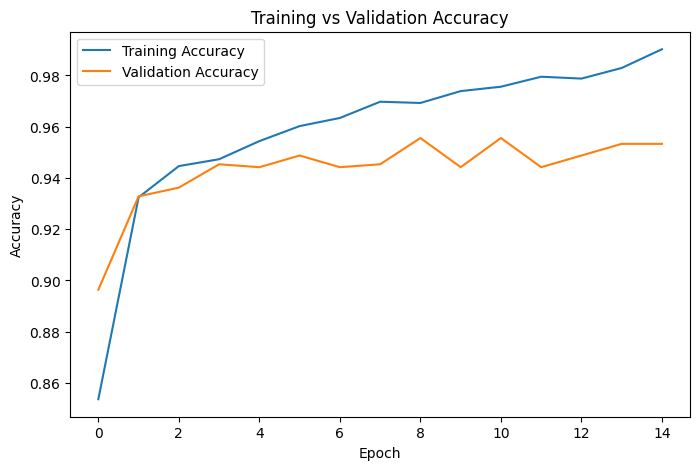

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.show()

In [55]:
test_loss, test_accuracy = model.evaluate(
    X_test_img,
    y_test_img,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9613 - loss: 0.1152
Test Loss: 0.11523379385471344
Test Accuracy: 0.9613196849822998


In [56]:
y_probability = model.predict(
    X_test_img
).ravel()

y_pred = (
    y_probability >= 0.5
).astype(int)

print("Predictions generated successfully.")

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
Predictions generated successfully.


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test_img,
    y_pred
)

precision = precision_score(
    y_test_img,
    y_pred
)

recall = recall_score(
    y_test_img,
    y_pred
)

f1 = f1_score(
    y_test_img,
    y_pred
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.9613
Precision: 0.9795
Recall   : 0.9672
F1-Score : 0.9733


In [58]:
from sklearn.metrics import roc_auc_score

auroc = roc_auc_score(
    y_test_img,
    y_probability
)

print(
    "AUROC:",
    round(auroc, 4)
)

AUROC: 0.9929


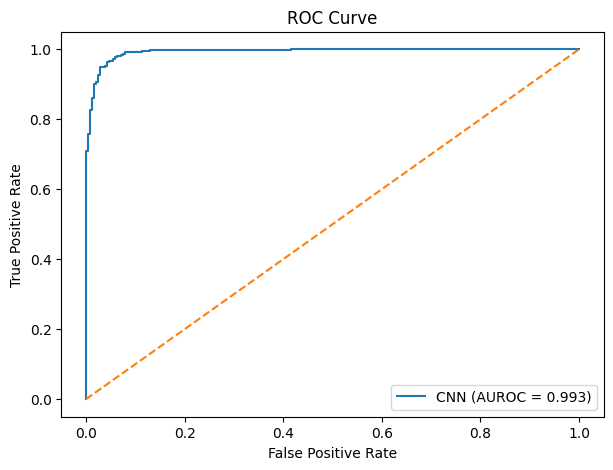

In [59]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test_img,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"CNN (AUROC = {auroc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test_img,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[225  13]
 [ 21 620]]


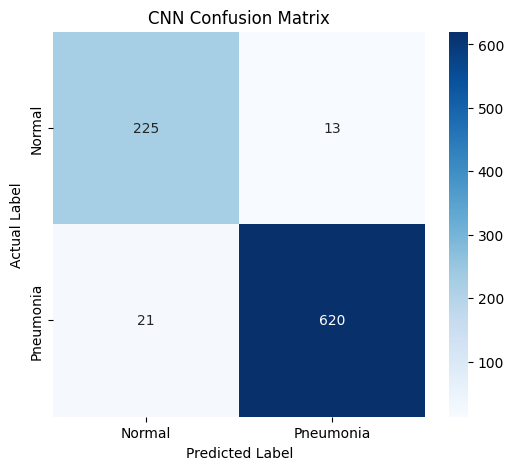

In [61]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",

    xticklabels=[
        "Normal",
        "Pneumonia"
    ],

    yticklabels=[
        "Normal",
        "Pneumonia"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title(
    "CNN Confusion Matrix"
)

plt.show()

In [62]:
results = pd.DataFrame({
    "Model": ["Baseline CNN"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1],
    "AUROC": [auroc]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,AUROC
0,Baseline CNN,0.96132,0.979463,0.967239,0.973312,0.992921


In [63]:
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras import layers, models

In [64]:
def create_tuned_cnn(
    learning_rate=0.001,
    dropout_rate=0.5
):

    model = models.Sequential([

        layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            input_shape=(128, 128, 1)
        ),

        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            128,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(dropout_rate),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [65]:
learning_rates = [
    0.001,
    0.0001
]

dropout_rates = [
    0.3,
    0.5
]

In [66]:
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_results = []

for lr in learning_rates:

    for dropout in dropout_rates:

        print("\n" + "=" * 60)
        print(
            "Learning Rate:",
            lr,
            "| Dropout:",
            dropout
        )
        print("=" * 60)

        fold_accuracies = []

        for fold, (train_idx, val_idx) in enumerate(
            skf.split(X_train_img, y_train_img),
            start=1
        ):

            print(f"\nFold {fold}/3")

            model_cv = create_tuned_cnn(
                learning_rate=lr,
                dropout_rate=dropout
            )

            model_cv.fit(
                X_train_img[train_idx],
                y_train_img[train_idx],
                validation_data=(
                    X_train_img[val_idx],
                    y_train_img[val_idx]
                ),
                epochs=5,
                batch_size=32,
                verbose=0
            )

            _, fold_accuracy = model_cv.evaluate(
                X_train_img[val_idx],
                y_train_img[val_idx],
                verbose=0
            )

            fold_accuracies.append(
                fold_accuracy
            )

            print(
                "Validation Accuracy:",
                round(fold_accuracy, 4)
            )

        mean_accuracy = np.mean(
            fold_accuracies
        )

        cv_results.append({
            "Learning Rate": lr,
            "Dropout": dropout,
            "Fold 1 Accuracy": fold_accuracies[0],
            "Fold 2 Accuracy": fold_accuracies[1],
            "Fold 3 Accuracy": fold_accuracies[2],
            "Mean CV Accuracy": mean_accuracy
        })

        print(
            "Mean CV Accuracy:",
            round(mean_accuracy, 4)
        )


Learning Rate: 0.001 | Dropout: 0.3

Fold 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9459

Fold 2/3
Validation Accuracy: 0.9407

Fold 3/3
Validation Accuracy: 0.9488
Mean CV Accuracy: 0.9451

Learning Rate: 0.001 | Dropout: 0.5

Fold 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9407

Fold 2/3
Validation Accuracy: 0.9451

Fold 3/3
Validation Accuracy: 0.9546
Mean CV Accuracy: 0.9468

Learning Rate: 0.0001 | Dropout: 0.3

Fold 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9356

Fold 2/3
Validation Accuracy: 0.9334

Fold 3/3
Validation Accuracy: 0.9429
Mean CV Accuracy: 0.9373

Learning Rate: 0.0001 | Dropout: 0.5

Fold 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.932

Fold 2/3
Validation Accuracy: 0.9217

Fold 3/3
Validation Accuracy: 0.9297
Mean CV Accuracy: 0.9278


In [69]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean CV Accuracy",
    ascending=False
)

cv_results_df

,Learning Rate,Dropout,Fold 1 Accuracy,Fold 2 Accuracy,Fold 3 Accuracy,Mean CV Accuracy
1,0.0010,0.5,0.940746,0.945095,0.954612,0.946818
0,0.0010,0.3,0.945867,0.940703,0.948756,0.945108
2,0.0001,0.3,0.935625,0.933382,0.942899,0.937302
3,0.0001,0.5,0.931968,0.921669,0.929722,0.927786


In [70]:
best_params = cv_results_df.iloc[0]

best_lr = best_params["Learning Rate"]
best_dropout = best_params["Dropout"]

print("Best Learning Rate:", best_lr)
print("Best Dropout:", best_dropout)
print(
    "Best Mean CV Accuracy:",
    round(best_params["Mean CV Accuracy"], 4)
)

Best Learning Rate: 0.001
Best Dropout: 0.5
Best Mean CV Accuracy: 0.9468


In [71]:
tuned_model = create_tuned_cnn(
    learning_rate=best_lr,
    dropout_rate=best_dropout
)

tuned_history = tuned_model.fit(
    X_train_img,
    y_train_img,

    validation_data=(
        X_val_img,
        y_val_img
    ),

    epochs=15,
    batch_size=32,

    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.8134 - loss: 0.4094 - val_accuracy: 0.9191 - val_loss: 0.1983
Epoch 2/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9129 - loss: 0.2123 - val_accuracy: 0.9248 - val_loss: 0.1854
Epoch 3/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9312 - loss: 0.1871 - val_accuracy: 0.9214 - val_loss: 0.2055
Epoch 4/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9307 - loss: 0.1685 - val_accuracy: 0.9339 - val_loss: 0.1836
Epoch 5/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9436 - loss: 0.1557 - val_accuracy: 0.9260 - val_loss: 0.1865
Epoch 6/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9485 - loss: 0.1402 - val_accuracy: 0.9385 - val_loss: 0.1497
Epoch 7/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9551 - loss: 0.1276 - val_accuracy: 0.9294 - val_loss: 0.1651
Epoch 8/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9515 - loss: 0.1271 - val_accu

In [72]:
tuned_test_loss, tuned_test_accuracy = tuned_model.evaluate(
    X_test_img,
    y_test_img,
    verbose=1
)

print("Tuned CNN Test Loss:", tuned_test_loss)
print("Tuned CNN Test Accuracy:", tuned_test_accuracy)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9625 - loss: 0.1140
Tuned CNN Test Loss: 0.11397825926542282
Tuned CNN Test Accuracy: 0.9624573588371277


In [73]:
tuned_probability = tuned_model.predict(
    X_test_img
).ravel()

tuned_pred = (
    tuned_probability >= 0.5
).astype(int)

print("Predictions generated successfully.")

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
Predictions generated successfully.


In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

tuned_accuracy = accuracy_score(
    y_test_img,
    tuned_pred
)

tuned_precision = precision_score(
    y_test_img,
    tuned_pred
)

tuned_recall = recall_score(
    y_test_img,
    tuned_pred
)

tuned_f1 = f1_score(
    y_test_img,
    tuned_pred
)

tuned_auroc = roc_auc_score(
    y_test_img,
    tuned_probability
)

print("TUNED CNN RESULTS")
print("-----------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1-Score :", round(tuned_f1, 4))
print("AUROC    :", round(tuned_auroc, 4))

TUNED CNN RESULTS
-----------------------------
Accuracy : 0.9625
Precision: 0.9663
Recall   : 0.9828
F1-Score : 0.9745
AUROC    : 0.9906


In [75]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Tuned CNN"
    ],

    "Accuracy": [
        accuracy,
        tuned_accuracy
    ],

    "Precision": [
        precision,
        tuned_precision
    ],

    "Recall": [
        recall,
        tuned_recall
    ],

    "F1-Score": [
        f1,
        tuned_f1
    ],

    "AUROC": [
        auroc,
        tuned_auroc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,AUROC
0,Baseline CNN,0.961320,0.979463,0.967239,0.973312,0.992921
1,Tuned CNN,0.962457,0.966258,0.982839,0.974478,0.990620


In [76]:
from sklearn.metrics import confusion_matrix

tuned_cm = confusion_matrix(
    y_test_img,
    tuned_pred
)

print("Tuned CNN Confusion Matrix:")
print(tuned_cm)

Tuned CNN Confusion Matrix:
[[216  22]
 [ 11 630]]


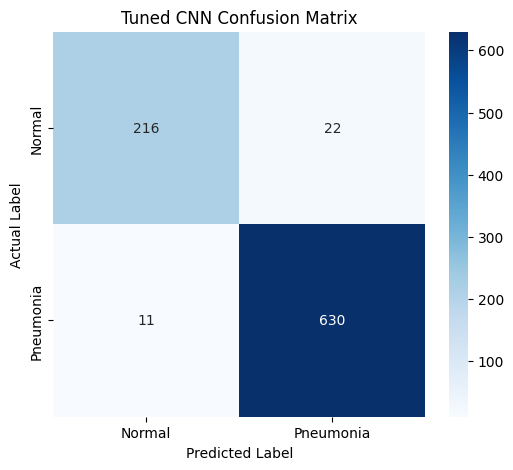

In [77]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Pneumonia"
    ],
    yticklabels=[
        "Normal",
        "Pneumonia"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Tuned CNN Confusion Matrix")

plt.show()